# AIMLCZG546 - Software Engineering for Machine Learning
## Assignment I: Real-Time Product Recommendation for an E-commerce Platform
**Domain:** E-commerce / Retail   **Architectural patterns:** Event-Driven Architecture + API Gateway
**Model:** Item-based Collaborative Filtering (cosine similarity)

**Group No:** G49

| Sl. | BITS ID | Name | Contribution (qualitative) | % |
|---|---|---|---|---|
| 1 | 2025aa05877 | VIVEK KUMAR AGARWAL | Requirements: problem statement, requirements, measurable goals, quality requirements | 25 |
| 2 | [Enter BITS ID] | [Enter Name] | GR4ML Business, Analytics Design and Data Preparation views | 25 |
| 3 | [Enter BITS ID] | [Enter Name] | Architecture diagram and pattern selection / justification | 25 |
| 4 | [Enter BITS ID] | [Enter Name] | Code, run evidence, screenshots, and code explanation | 25 |

> This notebook is the executable companion to the Word report. It reproduces the
> recommendation logic and both selected architectural patterns end-to-end.
> **To regenerate live outputs:** `pip install -r ../event_driven_prototype/requirements.txt`
> then run all cells. All results are deterministic (fixed seeds), so they match the
> recorded values and the figures in the report.

## How this notebook maps to the assignment

| Requirement | Where |
|---|---|
| Domain and ML problem statement | Section 1 (below) + report 1.1 |
| Requirements and measurable goals (GR4ML) | report 1.2-1.3 |
| GR4ML Business / Analytics Design / Data Preparation views | report Figures 1-3 |
| Top three quality requirements | report 1.4 |
| Architecture with ML and non-ML components | Section 2 + report Figure 4 |
| Two architectural patterns (Event-Driven + API Gateway) | Sections 3-4 |
| Pattern implementation + executed output | Sections 3-5 (this notebook) |

**Runnable services** (the report live screenshots come from these):
`event_driven_prototype/recommendation_api.py` (internal service, port 8001) and
`event_driven_prototype/api_gateway.py` (public gateway, port 8000).

## Section 1 - Problem and ML formulation

Given implicit-feedback events (`view`, `click`, `cart`, `purchase`), learn product
affinity and return a personalized **Top-N** list of previously unseen products for a
known user. Each action is weighted (`view=1, click=2, cart=3, purchase=5`), aggregated
into a user-item matrix, and turned into an **item-item cosine-similarity** model. A
user interaction vector multiplied by this similarity matrix yields item scores;
already-seen products are masked before ranking.

In [1]:
from __future__ import annotations

import json
import time
from datetime import datetime, timezone
from queue import Queue, Empty
from threading import Event, Thread, RLock
from typing import Any

import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

print("Environment ready. numpy", np.__version__)

Environment ready. numpy 2.4.6


### 1.1 In-memory feature store + item-based collaborative filtering (ML component)

This is the ML core (`recommender_engine.py`). It keeps the interaction matrix, refreshes
item-item similarity, applies weighted events, ranks unseen items, and computes an offline
Precision@k with a leave-three-out protocol.

In [2]:
USERS = [f"u{i}" for i in range(1, 61)]
ITEMS = [f"P{i:02d}" for i in range(1, 41)]
USER_INDEX = {u: i for i, u in enumerate(USERS)}
ITEM_INDEX = {p: i for i, p in enumerate(ITEMS)}
ACTION_WEIGHT = {"view": 1.0, "click": 2.0, "cart": 3.0, "purchase": 5.0}

_LOCK = RLock()
_MATRIX = np.zeros((len(USERS), len(ITEMS)), dtype=float)
_ITEM_SIMILARITY = np.zeros((len(ITEMS), len(ITEMS)), dtype=float)
_EVENT_COUNT = 0
_LAST_EVENT_AT = None
_SEEDED = False


def seed_demo_data() -> None:
    """Create repeatable clustered shopping behaviour (fixed seed => reproducible)."""
    global _EVENT_COUNT, _SEEDED
    with _LOCK:
        if _SEEDED:
            return
        rng = np.random.default_rng(546)
        for user_index, _ in enumerate(USERS):
            cluster = user_index % 4
            core = np.arange(cluster * 10, cluster * 10 + 10)
            neigh = np.arange(((cluster + 1) % 4) * 10, ((cluster + 1) % 4) * 10 + 10)
            selected = np.concatenate([rng.choice(core, size=7, replace=False),
                                       rng.choice(neigh, size=2, replace=False)])
            for item_index in selected:
                _MATRIX[user_index, item_index] += float(
                    rng.choice([1.0, 2.0, 3.0, 5.0], p=[0.25, 0.35, 0.25, 0.15]))
                _EVENT_COUNT += 1
        _refresh_similarity_locked()
        _SEEDED = True


def _refresh_similarity_locked() -> None:
    global _ITEM_SIMILARITY
    if np.count_nonzero(_MATRIX) == 0:
        _ITEM_SIMILARITY = np.zeros((len(ITEMS), len(ITEMS)), dtype=float)
        return
    _ITEM_SIMILARITY = cosine_similarity(_MATRIX.T)
    np.fill_diagonal(_ITEM_SIMILARITY, 0.0)


def validate_event(user_id: str, item_id: str, action: str) -> None:
    if user_id not in USER_INDEX:
        raise ValueError(f"unknown user_id: {user_id}")
    if item_id not in ITEM_INDEX:
        raise ValueError(f"unknown item_id: {item_id}")
    if action not in ACTION_WEIGHT:
        raise ValueError(f"invalid action: {action}")


def track_event(user_id: str, item_id: str, action: str) -> dict:
    """Apply one activity event to the interaction matrix (stronger action => more weight)."""
    global _EVENT_COUNT, _LAST_EVENT_AT
    seed_demo_data()
    validate_event(user_id, item_id, action)
    with _LOCK:
        _MATRIX[USER_INDEX[user_id], ITEM_INDEX[item_id]] += ACTION_WEIGHT[action]
        _EVENT_COUNT += 1
        _LAST_EVENT_AT = datetime.now(timezone.utc).isoformat(timespec="seconds")
        _refresh_similarity_locked()
        return {"user_id": user_id, "item_id": item_id, "action": action,
                "weight": ACTION_WEIGHT[action], "event_count": _EVENT_COUNT}


def rank_items(user_id: str, k: int = 5) -> list:
    """Top-k unseen products: user vector x item-item similarity, mask seen items."""
    seed_demo_data()
    if user_id not in USER_INDEX:
        raise ValueError(f"unknown user_id: {user_id}")
    with _LOCK:
        user_row = _MATRIX[USER_INDEX[user_id]].copy()
        scores = (user_row @ _ITEM_SIMILARITY).astype(float, copy=True)
        scores[user_row > 0] = -np.inf
        ordered = np.argsort(np.nan_to_num(scores, neginf=-1e12))[::-1]
        out = []
        for i in ordered:
            if len(out) == k:
                break
            if user_row[i] > 0:
                continue
            s = scores[i]
            out.append({"item_id": ITEMS[i], "score": round(float(s if np.isfinite(s) else 0.0), 3)})
        return out


def stats() -> dict:
    seed_demo_data()
    with _LOCK:
        return {"users": len(USERS), "items": len(ITEMS), "events_processed": _EVENT_COUNT,
                "matrix_density": round(float(np.count_nonzero(_MATRIX) / _MATRIX.size), 4)}


def evaluate_precision_at_k(k: int = 5, holdout_per_user: int = 3) -> dict:
    """Leave-three-out offline Precision@k on the seeded interactions."""
    seed_demo_data()
    with _LOCK:
        full = _MATRIX.copy()
    rng = np.random.default_rng(1546)
    train = full.copy()
    held = {}
    for u in range(full.shape[0]):
        pos = np.flatnonzero(full[u] > 0)
        if len(pos) <= holdout_per_user:
            continue
        h = rng.choice(pos, size=holdout_per_user, replace=False)
        train[u, h] = 0.0
        held[u] = set(int(x) for x in h)
    sim = cosine_similarity(train.T)
    np.fill_diagonal(sim, 0.0)
    prec, hit_users = [], 0
    for u, h in held.items():
        sc = train[u] @ sim
        sc[train[u] > 0] = -np.inf
        top = np.argsort(np.nan_to_num(sc, neginf=-1e12))[::-1][:k]
        hits = len(set(int(x) for x in top) & h)
        hit_users += 1 if hits else 0
        prec.append(hits / k)
    return {"metric": f"Precision@{k}", "value": round(float(np.mean(prec)) if prec else 0.0, 3),
            "evaluated_users": len(prec), "users_with_at_least_one_hit": hit_users,
            "holdout_per_user": holdout_per_user}

print("Engine loaded:", len(USERS), "users x", len(ITEMS), "items")

Engine loaded: 60 users x 40 items


In [3]:
seed_demo_data()
print("Feature store after seeding:", stats())

Feature store after seeding: {'users': 60, 'items': 40, 'events_processed': 540, 'matrix_density': 0.225}


**Recorded output** (deterministic): `{'users': 60, 'items': 40, 'events_processed': 540, 'matrix_density': 0.225}`

## Section 2 - System architecture (ML and non-ML components)

![System architecture](../event_driven_prototype/evidence/system_architecture.png)

Storefront -> **API Gateway** (auth, rate-limit, route) -> **Event tracking** -> **Message
broker / queue** -> **Event consumer** (updates features) -> **Feature store**; the
**Recommendation service (ML)** reads features and serves through a **cache**. Non-ML:
gateway, tracking, broker, consumer, cache. ML: recommendation service. Data stores:
feature store, cache.

## Section 3 - Pattern 1: Event-Driven Architecture

Activity events are accepted quickly and placed on a queue; a **background consumer**
updates the recommendation features asynchronously, so write traffic never blocks reads.
The cell below reproduces exactly that flow in-process (producer -> queue -> consumer thread).

In [4]:
# Event-Driven pattern: producer puts events on a queue; a background consumer drains it.
EVENT_QUEUE = Queue()
STOP_WORKER = Event()

def consumer_loop() -> None:
    while not STOP_WORKER.is_set():
        try:
            event = EVENT_QUEUE.get(timeout=0.2)
        except Empty:
            continue
        try:
            result = track_event(event["user_id"], event["item_id"], event["action"])
            print("  consumer processed:", result["item_id"], result["action"],
                  "-> total events", result["event_count"], flush=True)
        finally:
            EVENT_QUEUE.task_done()

worker = Thread(target=consumer_loop, daemon=True, name="event-consumer")
worker.start()

# One user browsing, adding to cart, and purchasing (same scenario as the report demo).
demo_events = [
    {"user_id": "u7", "item_id": "P03", "action": "click"},
    {"user_id": "u7", "item_id": "P04", "action": "cart"},
    {"user_id": "u7", "item_id": "P12", "action": "purchase"},
]
for e in demo_events:
    EVENT_QUEUE.put(e)
    print("POST /track accepted (202) -> queued:", e, flush=True)

EVENT_QUEUE.join()          # wait for the async consumer to finish
STOP_WORKER.set()
print("\nQueue drained. Feature store now:", stats())

POST /track accepted (202) -> queued: {'user_id': 'u7', 'item_id': 'P03', 'action': 'click'}
  consumer processed: P03 click -> total events 541


POST /track accepted (202) -> queued: {'user_id': 'u7', 'item_id': 'P04', 'action': 'cart'}
  consumer processed: P04 cart -> total events 542


POST /track accepted (202) -> queued: {'user_id': 'u7', 'item_id': 'P12', 'action': 'purchase'}


  consumer processed: P12 purchase -> total events 543



Queue drained. Feature store now: {'users': 60, 'items': 40, 'events_processed': 543, 'matrix_density': 0.2263}


**Recorded output** (deterministic): after the three queued events are consumed,
`events_processed` becomes **543** and `matrix_density` **0.2263** - the write side updated
the model asynchronously, exactly as in the report.

## Section 4 - Pattern 2: API Gateway

The gateway is the single public entry point: it validates a bearer token, applies a small
rate limit, and routes to internal services. Clients never call the internal recommendation
service directly. The runnable implementation is `event_driven_prototype/api_gateway.py`;
the core route is shown below.

```python
# event_driven_prototype/api_gateway.py  (Pattern 2: API Gateway)
@app.get("/recommend")
async def recommend(user_id: str, k: int = 5,
                    authorization: str | None = Header(default=None)) -> Any:
    require_token(authorization)                 # centralised auth
    enforce_rate_limit(f"recommend:{user_id}")   # centralised rate limiting
    async with httpx.AsyncClient(timeout=5.0) as client:
        response = await client.get(f"{RECO_SERVICE}/rank",
                                    params={"user_id": user_id, "k": k})
    payload = await forward_response(response)
    payload["served_by"] = "api-gateway"
    payload["pattern"]  = "api-gateway"
    return payload

# event_driven_prototype/recommendation_api.py  (Pattern 1: Event-Driven)
@app.post("/track", status_code=202)
def track(event: ActivityEvent) -> dict:
    recommender_engine.validate_event(event.user_id, event.item_id, event.action)
    EVENT_QUEUE.put(event.model_dump())          # accept fast, process async
    return {"status": "accepted", "pattern": "event-driven",
            "queued_events": EVENT_QUEUE.qsize(), "event": event.model_dump()}
```
Run the two services and the demo client to reproduce the report screenshots:
```bash
python -m uvicorn recommendation_api:app --port 8001   # internal service
python -m uvicorn api_gateway:app --port 8000          # public gateway
python demo_requests.py                                # events + recommendation via gateway
```

## Section 5 - Executed recommendation and offline evaluation

In [5]:
recs = rank_items("u7", 5)
print("GET /recommend?user_id=u7&k=5  (served_by=api-gateway)")
print(json.dumps({"user_id": "u7",
                  "strategy": "item-based-collaborative-filtering",
                  "recommendations": recs}, indent=2))

GET /recommend?user_id=u7&k=5  (served_by=api-gateway)
{
  "user_id": "u7",
  "strategy": "item-based-collaborative-filtering",
  "recommendations": [
    {
      "item_id": "P28",
      "score": 10.027
    },
    {
      "item_id": "P25",
      "score": 9.243
    },
    {
      "item_id": "P21",
      "score": 8.805
    },
    {
      "item_id": "P16",
      "score": 6.136
    },
    {
      "item_id": "P40",
      "score": 5.802
    }
  ]
}


**Recorded output** (deterministic): top-5 unseen products for `u7` are
**P28 (10.027), P25 (9.243), P21 (8.805), P16 (6.136), P40 (5.802)** - matching the report.

In [6]:
metric = evaluate_precision_at_k(k=5, holdout_per_user=3)
print("Offline evaluation:", metric)
verdict = "PASS" if metric["value"] >= 0.30 else "FAIL"
print(f"\nPrecision@5 = {metric['value']}  (target >= 0.30 -> {verdict})")

Offline evaluation: {'metric': 'Precision@5', 'value': 0.323, 'evaluated_users': 60, 'users_with_at_least_one_hit': 53, 'holdout_per_user': 3}

Precision@5 = 0.323  (target >= 0.30 -> PASS)


**Recorded output** (deterministic): `Precision@5 = 0.323`, evaluated_users = 60,
users_with_at_least_one_hit = 53 -> clears the >= 0.30 target.

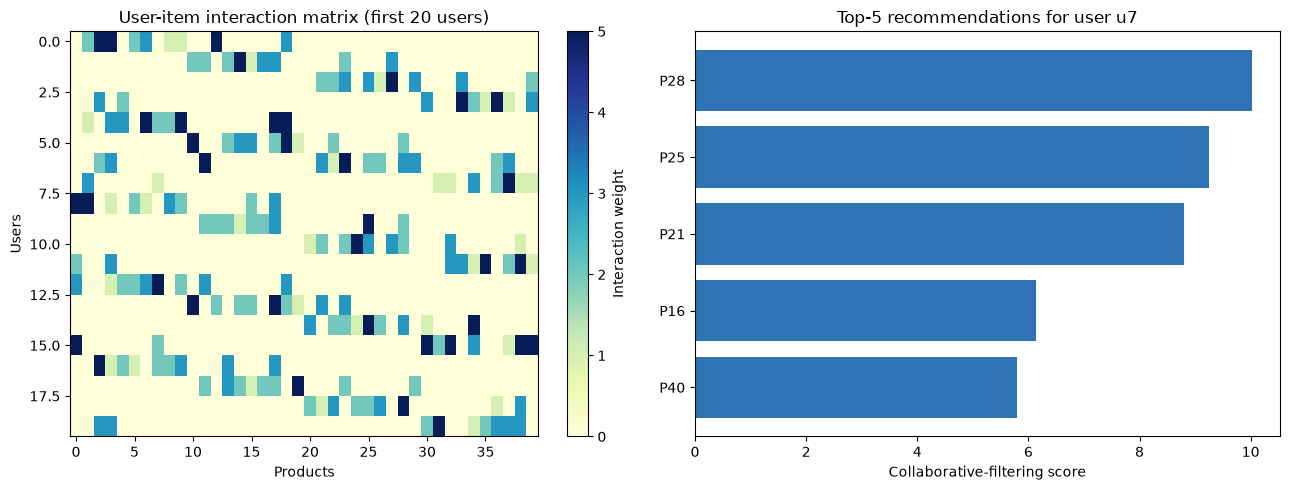

In [7]:
# Optional: reproduce the evidence figure (interaction matrix + top-5). Falls back gracefully.
try:
    import matplotlib.pyplot as plt
    with _LOCK:
        snap = _MATRIX.copy()
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    im = ax1.imshow(snap[:20], aspect="auto", cmap="YlGnBu")
    ax1.set_title("User-item interaction matrix (first 20 users)")
    ax1.set_xlabel("Products"); ax1.set_ylabel("Users")
    fig.colorbar(im, ax=ax1, label="Interaction weight")
    labels = [r["item_id"] for r in recs][::-1]
    values = [r["score"] for r in recs][::-1]
    ax2.barh(labels, values, color="#2E74B5")
    ax2.set_title("Top-5 recommendations for user u7")
    ax2.set_xlabel("Collaborative-filtering score")
    plt.tight_layout(); plt.show()
except ImportError:
    print("matplotlib not installed; see event_driven_prototype/evidence/recommendation_output_plot.png")

## Section 6 - Top three quality requirements (summary)

| Quality requirement | Justification | Design decision |
|---|---|---|
| Low latency | Recommendations render inline while the shopper browses | Precompute item similarity, cache top-N, keep the read path simple |
| Scalability / elasticity | Traffic is bursty during campaigns | Event-driven broker/queue + independently scalable consumers |
| Recommendation relevance | Poor suggestions waste screen space and erode trust | Interaction weights, item similarity, seen-item filtering, Precision@5, coverage |

## Limitations and future work
Academic prototype: small deterministic dataset and in-memory queue. Production would use
Kafka / Redis Streams, a persistent feature store, and monitoring for latency, event lag,
Precision@5, coverage, drift, and online CTR uplift via A/B testing.

## References
- Nalchigar & Yu (2020). Designing Business Analytics Solutions: A Model-Driven Approach. BISE 62(1).
- Sarwar, Karypis, Konstan, Riedl (2001). Item-based collaborative filtering recommendation algorithms. WWW 2001.
- FastAPI documentation; scikit-learn cosine_similarity documentation.

*Full requirements, GR4ML views (Figures 1-3), architecture (Figure 4), and live API
screenshots (Figures 5-9) are in the accompanying Word report.*